# 2. 평가 — 그림 + 통계치 저장

`result/predictions/*.csv` 를 로드해 지표를 계산하고,
- **통계치** → `result/statistics/metrics.csv`, `stage_r2.csv`
- **그림** → `result/image/metric_bars.png`, `scatter_grid.png`, `stage_r2.png`

**지표**: R²(설명력), MAE/RMSE(오차, 작을수록↑), Spearman ρ(순위 일치도, 높을수록↑ — 상대가치 랭킹).

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from util import utils, file_manager as fm, plot
from util.metric import metrics, stage_r2
from module import data, infer

# 저장된 model weight 을 로드해 OOS test set 을 직접 forward (예측 CSV 미로드 → 가중치→예측 재현)
# 전 모델이 이론가(MC) 예측 (y_true=MC): 벤치마크=직접(단일 단계), DeepONet/XGB=하이브리드(2단계).
cfg = utils.load_config()
D = data.load(cfg)
preds = infer.predict_all_from_weights(D, cfg)
print("predicted from saved weights:", list(preds.keys()))

predicted from saved weights: ['bench_ridge', 'bench_gbm', 'bench_lgbm', 'bench_xgboost', 'bench_catboost', 'deeponet_hybrid', 'deeponet_hybrid_l1', 'deeponet_hybrid_mape', 'deeponet_hybrid_s2don', 'xgb_hybrid']


In [13]:
# 지표 표
rows, scat = [], {}
for name, df in preds.items():
    rows.append({"model": name, **metrics(df["y_true"], df["y_pred"])})
    scat[name] = (df["y_true"].values, df["y_pred"].values)
mt = pd.DataFrame(rows).set_index("model").sort_values("R2", ascending=False)
mt.to_csv(fm.stat("metrics"))
print(mt.round(4).to_string())

                           R2     MAE    RMSE   MAPE%  MdAPE%   Bias%  Spearman
model                                                                          
deeponet_hybrid_l1     0.9611  0.0036  0.0060  0.3728  0.2200 -0.1230    0.9872
deeponet_hybrid_mape   0.9594  0.0035  0.0061  0.3637  0.2003 -0.1207    0.9896
deeponet_hybrid        0.9571  0.0037  0.0063  0.3876  0.2183  0.0521    0.9787
deeponet_hybrid_s2don  0.9549  0.0037  0.0064  0.3801  0.2025  0.0927    0.9753
xgb_hybrid             0.9036  0.0061  0.0094  0.6314  0.3905 -0.2151    0.9630
bench_catboost         0.9024  0.0064  0.0094  0.6583  0.4424 -0.2868    0.9642
bench_xgboost          0.8539  0.0076  0.0115  0.7829  0.4679 -0.4483    0.9501
bench_gbm              0.8417  0.0081  0.0120  0.8356  0.5160 -0.4603    0.9453
bench_lgbm             0.8356  0.0081  0.0122  0.8394  0.4917 -0.5249    0.9523
bench_ridge            0.7010  0.0124  0.0165  1.2629  0.9586 -0.2692    0.8953


In [14]:
# stage별 R² (하이브리드)
st = {name: stage_r2(df) for name, df in preds.items() if stage_r2(df) is not None}
sdf = pd.DataFrame(st).T
sdf.to_csv(fm.stat("stage_r2"))
print(sdf.round(3).to_string())

                       stage1_MC_R2  stage2_resid_R2  final_MC_R2
deeponet_hybrid               0.951            0.126        0.957
deeponet_hybrid_l1            0.957            0.045        0.961
deeponet_hybrid_mape          0.950            0.153        0.959
deeponet_hybrid_s2don         0.949            0.109        0.955
xgb_hybrid                    0.897            0.005        0.904


## R² 상세 분석 — 과대평가(overprice) · 구간별 · 시간별

우리 MC는 자산별 **단일 역사변동성**(행사가별 스큐 없음 = 스큐가 평탄)이라 하방 꼬리위험을 과소반영 → 위험(저가) 구간에서 ELS를 **과대평가**하는 경향이 있다. 아래에서 모델별 **과대/과소평가(bias)**, 공정가치 **구간별 R²·MAPE·bias**, **발행시기별 R²**(시간 안정성), 그리고 **잔차-공정가치 곡선**(스큐 평탄화의 흔적)을 분해한다.

In [15]:
# 과대/과소평가(overprice) 분해 — bias>0 이면 평균적으로 과대평가 (단위: 원, 발행가 10,000)
import numpy as np
from sklearn.metrics import r2_score
FACE = 10000
base = next(iter(preds.values())).set_index("ITEM_CD")
idx = base.index
det = []
for name, df in preds.items():
    d = df.set_index("ITEM_CD").loc[idx]; yt = d["y_true"].values; yp = d["y_pred"].values
    e = yp - yt; over = e > 0                       # e>0 = 과대평가(overprice)
    det.append({"model": name, "R2": r2_score(yt, yp),
                "MAPE%": np.mean(np.abs(e) / np.abs(yt)) * 100,
                "over_frac%": over.mean() * 100,
                "bias_KRW": e.mean() * FACE,
                "overMAE_KRW": e[over].mean() * FACE if over.any() else 0.0,
                "underMAE_KRW": -e[~over].mean() * FACE if (~over).any() else 0.0})
detdf = pd.DataFrame(det).set_index("model").sort_values("R2", ascending=False)
detdf.to_csv(fm.stat("error_breakdown"))
print("과대/과소평가 분해 (over_frac% = 과대평가 비율, bias>0 = 과대평가):")
print(detdf.round(2).to_string())

과대/과소평가 분해 (over_frac% = 과대평가 비율, bias>0 = 과대평가):
                         R2  MAPE%  over_frac%   bias_KRW  overMAE_KRW  underMAE_KRW
model                                                                               
deeponet_hybrid_l1     0.96   0.37       35.11 -12.000000    34.000000     36.900002
deeponet_hybrid_mape   0.96   0.36       37.35 -11.680000    31.040001     37.150002
deeponet_hybrid        0.96   0.39       47.37   4.800000    44.529999     30.969999
deeponet_hybrid_s2don  0.95   0.38       49.76   8.670000    45.610001     27.900000
xgb_hybrid             0.90   0.63       43.02 -21.240000    46.490002     72.379997
bench_catboost         0.90   0.66       38.14 -28.600000    46.459999     74.870003
bench_xgboost          0.85   0.78       35.62 -44.060001    45.009998     93.339996
bench_gbm              0.84   0.84       37.50 -45.139999    48.180000    101.129997
bench_lgbm             0.84   0.84       35.75 -51.080002    42.529999    103.180000
bench_ridge    

In [16]:
# 공정가치 구간별 · 발행시기별 R² 분해 (핵심 모델)
KEY = [m for m in ["xgb_hybrid", "deeponet_hybrid", "deeponet_hybrid_l1", "deeponet_hybrid_mape",
                   "deeponet_hybrid_s2don", "bench_xgboost"] if m in preds]
fair = base["y_true"].values; ordv = base["isu_ord"].values
q = np.quantile(fair, [1/3, 2/3])
seg = np.where(fair <= q[0], "low(위험/저가)", np.where(fair <= q[1], "mid", "high(안전/고가)"))
segs = ["low(위험/저가)", "mid", "high(안전/고가)"]
print("=== 공정가치 3분위 구간별  R² / MAPE / bias(원) ===")
for name in KEY:
    d = preds[name].set_index("ITEM_CD").loc[idx]; yt = d["y_true"].values; yp = d["y_pred"].values
    print(f"[{name}]")
    for s in segs:
        m = seg == s; e = yp[m] - yt[m]
        print(f"   {s:14s} n={m.sum():5d}  R2={r2_score(yt[m], yp[m]):+.3f}  "
              f"MAPE={np.mean(np.abs(e)/np.abs(yt[m]))*100:5.2f}%  bias={e.mean()*FACE:+6.0f}원")
tb = np.quantile(ordv, [.25, .5, .75]); tbin = np.digitize(ordv, tb)
print("\n=== 발행시기 4구간별 R² (시간 안정성; P0=과거→P3=최근) ===")
for name in KEY:
    d = preds[name].set_index("ITEM_CD").loc[idx]; yt = d["y_true"].values; yp = d["y_pred"].values
    print(f"   {name:22s} " + "  ".join(f"P{b}:{r2_score(yt[tbin==b], yp[tbin==b]):+.3f}" for b in range(4)))

=== 공정가치 3분위 구간별  R² / MAPE / bias(원) ===
[xgb_hybrid]
   low(위험/저가)     n= 3087  R2=+0.722  MAPE= 0.92%  bias=   -22원
   mid            n= 3087  R2=-0.707  MAPE= 0.54%  bias=   -25원
   high(안전/고가)    n= 3087  R2=+0.430  MAPE= 0.43%  bias=   -17원
[deeponet_hybrid]
   low(위험/저가)     n= 3087  R2=+0.855  MAPE= 0.63%  bias=   +18원
   mid            n= 3087  R2=+0.392  MAPE= 0.29%  bias=    +0원
   high(안전/고가)    n= 3087  R2=+0.832  MAPE= 0.24%  bias=    -4원
[deeponet_hybrid_l1]
   low(위험/저가)     n= 3087  R2=+0.863  MAPE= 0.61%  bias=   -12원
   mid            n= 3087  R2=+0.520  MAPE= 0.28%  bias=   -14원
   high(안전/고가)    n= 3087  R2=+0.857  MAPE= 0.22%  bias=   -10원
[deeponet_hybrid_mape]
   low(위험/저가)     n= 3087  R2=+0.843  MAPE= 0.65%  bias=   -19원
   mid            n= 3087  R2=+0.633  MAPE= 0.24%  bias=    -9원
   high(안전/고가)    n= 3087  R2=+0.888  MAPE= 0.20%  bias=    -7원
[deeponet_hybrid_s2don]
   low(위험/저가)     n= 3087  R2=+0.850  MAPE= 0.61%  bias=   +24원
   mid            n= 3087  

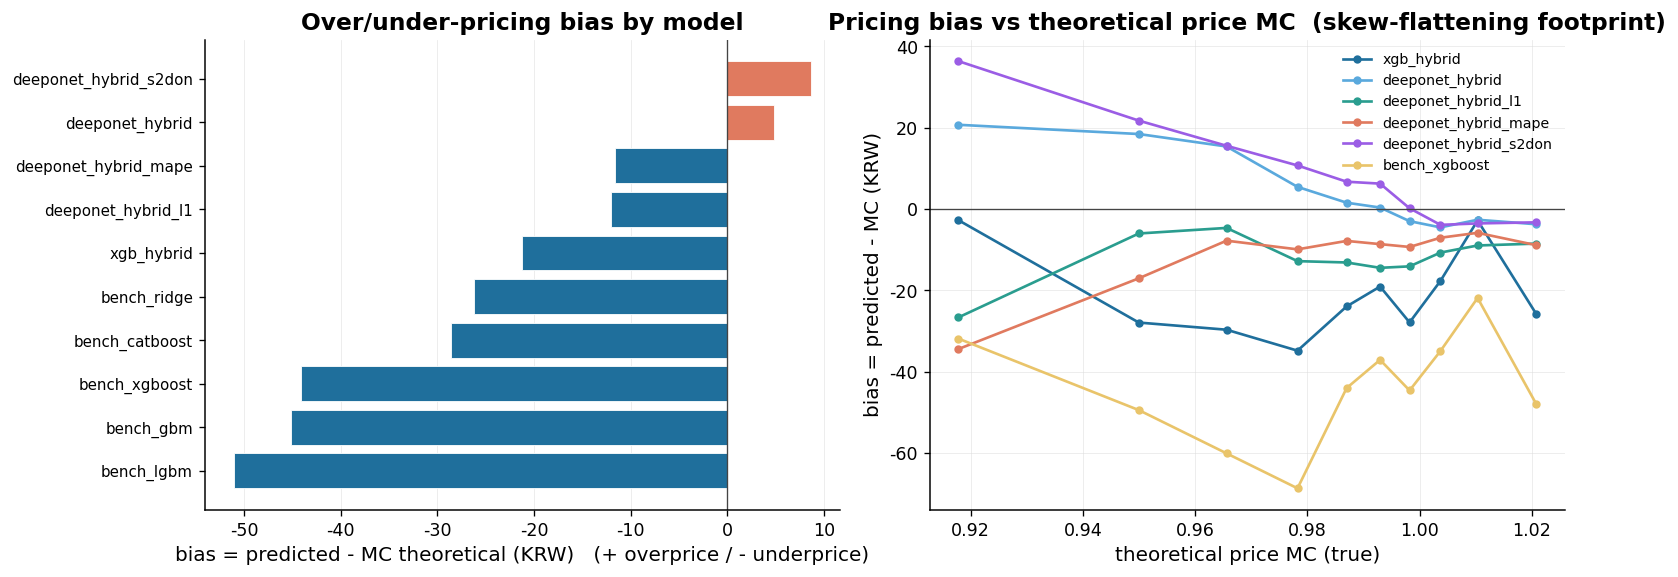

saved -> error_analysis.png  (bias = predicted - MC theoretical)


In [17]:
# 그림: (1) 모델별 과대/과소 bias  (2) bias vs 이론가(MC) 곡선 (스큐 평탄화 흔적)  [학술/PPT: dpi400·투명·콘텐츠밴드]
# bias = 예측 − 이론가(MC) (predicted − MC). 양수 = overprice(예측>이론가), 음수 = underprice.
from util import plot as _plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13.333, 5.0))
mm = detdf.sort_values("bias_KRW")
ax[0].barh(range(len(mm)), mm["bias_KRW"].values,
           color=np.where(mm["bias_KRW"].values > 0, "#e07a5f", "#1f6f9c"), edgecolor="white", linewidth=0.5)
ax[0].set_yticks(range(len(mm))); ax[0].set_yticklabels(mm.index, fontsize=9)
ax[0].axvline(0, color="#444", lw=.8)
ax[0].set_xlabel("bias = predicted - MC theoretical (KRW)   (+ overprice / - underprice)")
ax[0].set_title("Over/under-pricing bias by model")
ax[0].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6)
for j, name in enumerate(KEY):
    d = preds[name].set_index("ITEM_CD").loc[idx]; yt = d["y_true"].values; yp = d["y_pred"].values
    bins = np.quantile(yt, np.linspace(0, 1, 11)); ib = np.clip(np.digitize(yt, bins[1:-1]), 0, 9)
    xc = [yt[ib == k].mean() for k in range(10)]
    yb = [(yp[ib == k] - yt[ib == k]).mean() * FACE for k in range(10)]
    ax[1].plot(xc, yb, marker="o", ms=4, lw=1.6, color=_plot._QUAL[j % len(_plot._QUAL)], label=name)
ax[1].axhline(0, color="#444", lw=.8)
ax[1].set_xlabel("theoretical price MC (true)"); ax[1].set_ylabel("bias = predicted - MC (KRW)")
ax[1].set_title("Pricing bias vs theoretical price MC  (skew-flattening footprint)")
ax[1].grid(color="#dddddd", lw=0.5, alpha=0.6)
ax[1].legend(fontsize=8.5)
fig.tight_layout()
fig.savefig(fm.image("error_analysis"), dpi=400, bbox_inches="tight", transparent=True); plt.show()
print("saved -> error_analysis.png  (bias = predicted - MC theoretical)")

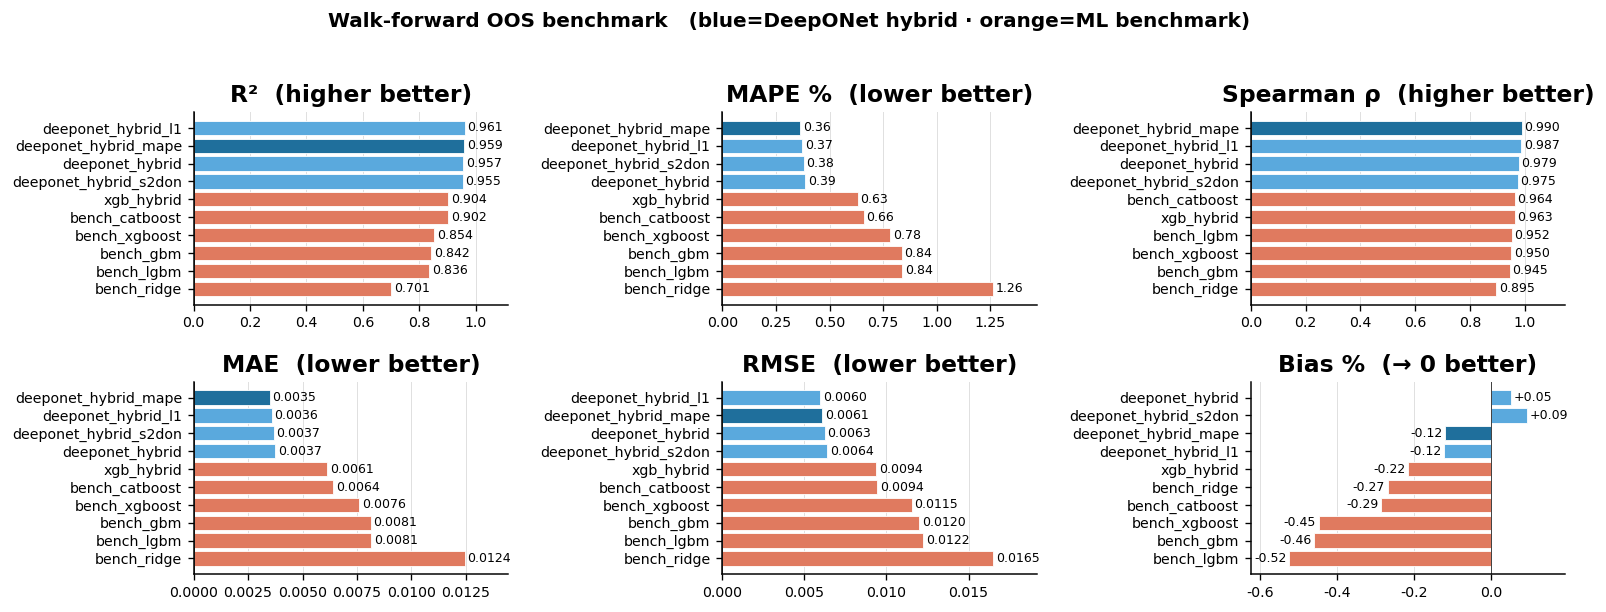

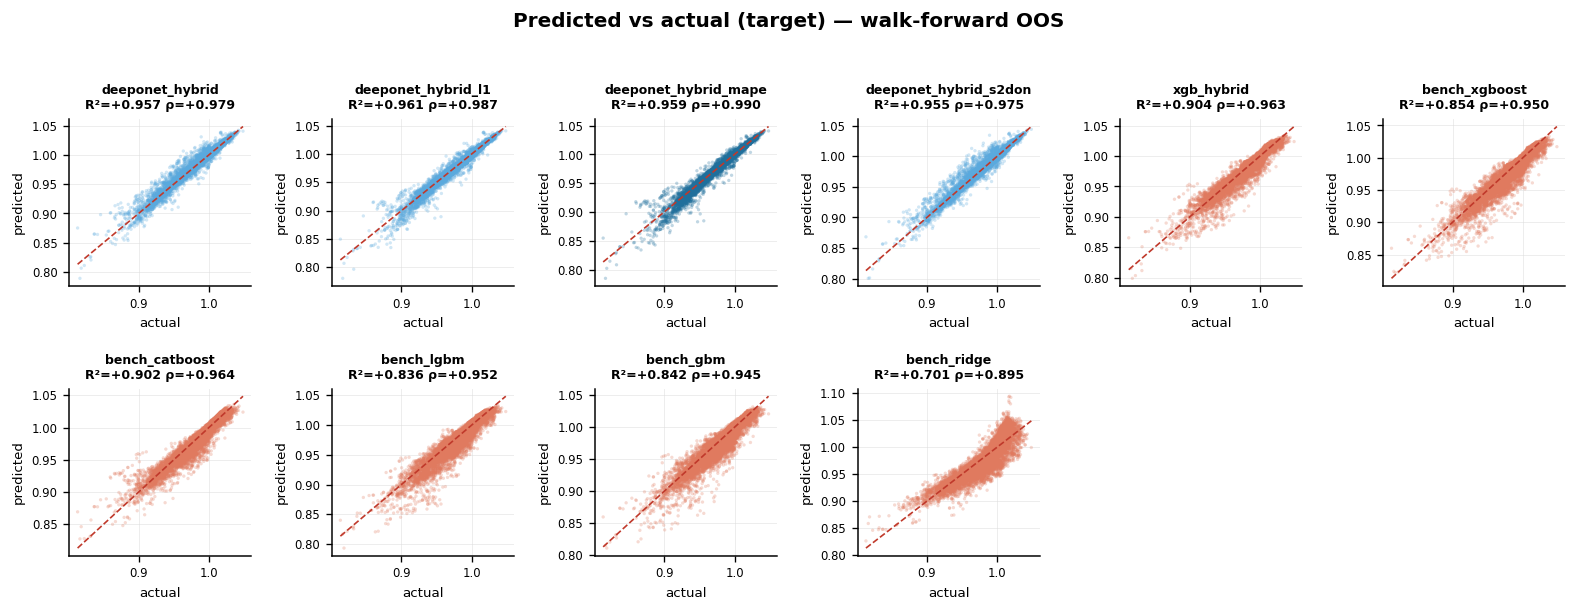

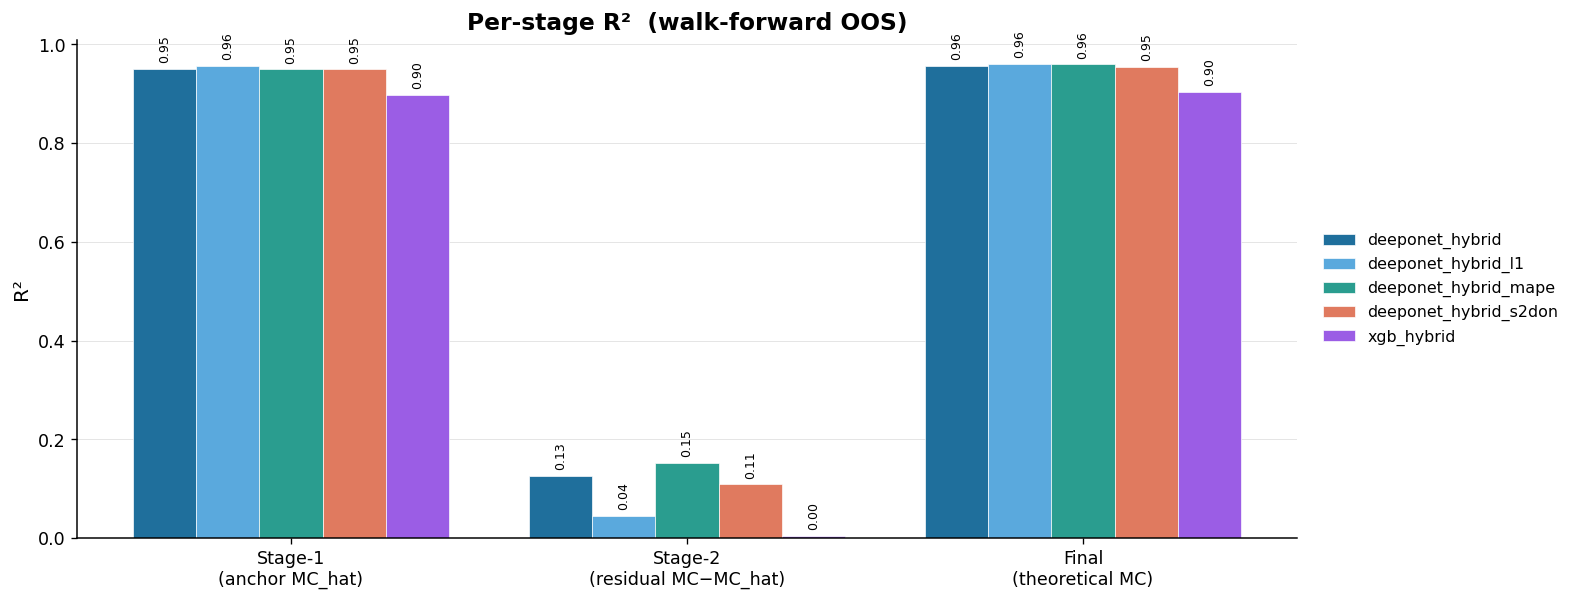

saved images -> ['error_analysis.png', 'exp_pi_ablation.png', 'exp_pi_results.png', 'exp_two_splits.png', 'fair_minus_mc_hist.png', 'impliedvol_rolling_match.png', 'inference_speed.png', 'mae_err_by_price_seg.png', 'mc_ci_calibration.png', 'mc_error_by_calibration.png', 'mc_error_by_segment.png', 'mc_error_heatmap_bk_vol.png', 'mc_error_precalib.png', 'mc_oos_drift_folds.png', 'mc_pred_ci_band.png', 'mc_pred_ci_calibrated.png', 'mc_vs_deeponet_speed.png', 'metric_bars.png', 'raw_fair_tenor_hist.png', 'raw_filter_funnel.png', 'scatter_grid.png', 'stage_r2.png']
saved stats  -> ['error_breakdown.csv', 'exp_pi_ablation_seed0.csv', 'exp_pi_walkforward.csv', 'exp_two_splits_seed0.csv', 'inference_speed.csv', 'metrics.csv', 'stage_r2.csv']


In [18]:
# 그림 저장 + 표시
ORDER = [
    "deeponet_hybrid",
    "deeponet_hybrid_l1",
    "deeponet_hybrid_mape",
    "deeponet_hybrid_s2don",
    "xgb_hybrid",
    "bench_xgboost",
    "bench_catboost",
    "bench_lgbm",
    "bench_gbm",
    "bench_ridge",
]
order = [m for m in ORDER if m in scat] + [m for m in scat if m not in ORDER]

plot.metric_bars(mt, fm.image("metric_bars"))
plot.scatter_grid(scat, order=order, path=fm.image("scatter_grid"))
if len(sdf):
    plot.stage_r2_bar(sdf, fm.image("stage_r2"))
plt.show()
print("saved images ->", [p.name for p in sorted(fm.IMAGE.glob("*.png"))])
print("saved stats  ->", [p.name for p in sorted(fm.STAT.glob("*.csv"))])

                         kind     n  batch_ms  per_product_us  products_per_sec
model                                                                          
deeponet_hybrid_s2don  hybrid  2315      2.26            0.97        1025697.83
bench_catboost         direct  2315      2.45            1.06         943992.50
bench_ridge            direct  2315      3.23            1.40         715743.26
deeponet_hybrid_mape   hybrid  2315      3.61            1.56         641043.39
deeponet_hybrid        hybrid  2315      3.77            1.63         614433.21
deeponet_hybrid_l1     hybrid  2315      3.96            1.71         584965.26
xgb_hybrid             hybrid  2315      4.90            2.12         472352.58
bench_xgboost          direct  2315      7.73            3.34         299354.74
bench_gbm              direct  2315      7.76            3.35         298309.37
bench_lgbm             direct  2315     10.21            4.41         226682.99


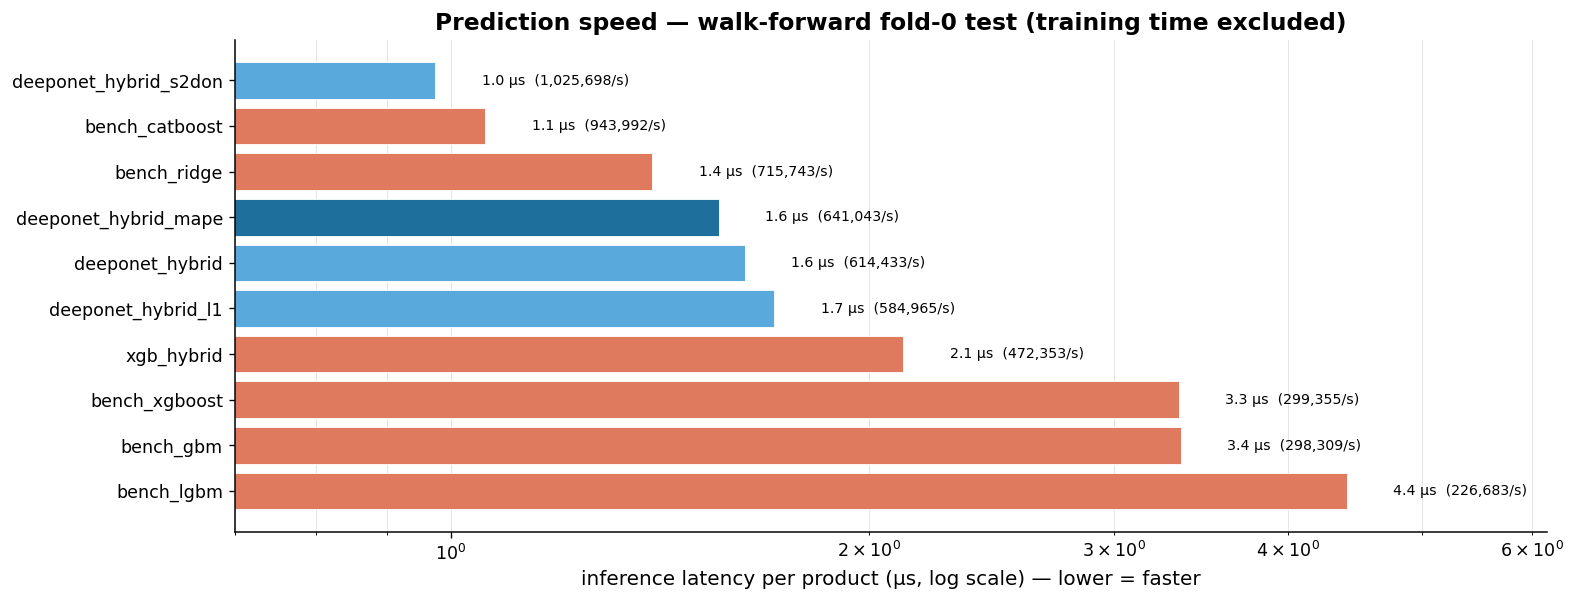

saved -> inference_speed.png | inference_speed.csv


In [19]:
# 예측(추론) 속도 측정 + 그래프  (학습 시간 제외, fold-0 test 기준)
from util import utils, speed
from module import data as _data
cfg = utils.load_config()
Dspd = _data.load(cfg)
spd = speed.measure(Dspd, cfg)
spd.to_csv(fm.stat("inference_speed"))
print(spd.round(2).to_string())
plot.speed_bar(spd, fm.image("inference_speed"))
plt.show()
print("saved ->", fm.image("inference_speed").name, "|", fm.stat("inference_speed").name)

## 이론가(MC) 예측 세분화 — 신뢰구간 모델 (`deeponet_hybrid_ci`)

`deeponet_hybrid_ci`(가우시안 NLL) 예측을 **세분화**해 발표용 그림을 저장한다.
- **예측±CI 밴드** (`mc_pred_ci_band`) — 상품을 실제 MC로 정렬, 예측·실제선 + 95% 신뢰밴드 (논문 Fig8 스타일)
- **오차 히트맵** (`mc_error_heatmap_bk_vol`) — 배리어/행사가(b/k) × 변동성 MAPE (어두운 셀 = 더 나은 target 이론가가 필요한 영역)
- **세분화 MAPE 바** (`mc_error_by_segment`) — 변동성·b/k·쿠폰·이론가 수준별
- **OOS 시간 드리프트** (`mc_oos_drift_folds`) — walk-forward 폴드별 R²·MAPE
- **신뢰구간 캘리브레이션** (`mc_ci_calibration`) — reliability curve + 변동성별 95% 커버리지

> 만기(TENOR)는 3년물 지배로 사실상 상수라 세분화 축에서 제외(분위수 붕괴). 대신 변동성·b/k·쿠폰·가격수준으로 세분화.
> CI 컬럼(`y_std/y_lo/y_hi`)은 가중치 재현(infer)에 없어 `result/predictions/deeponet_hybrid_ci.csv`(2_run 산출)에서 로드한다.

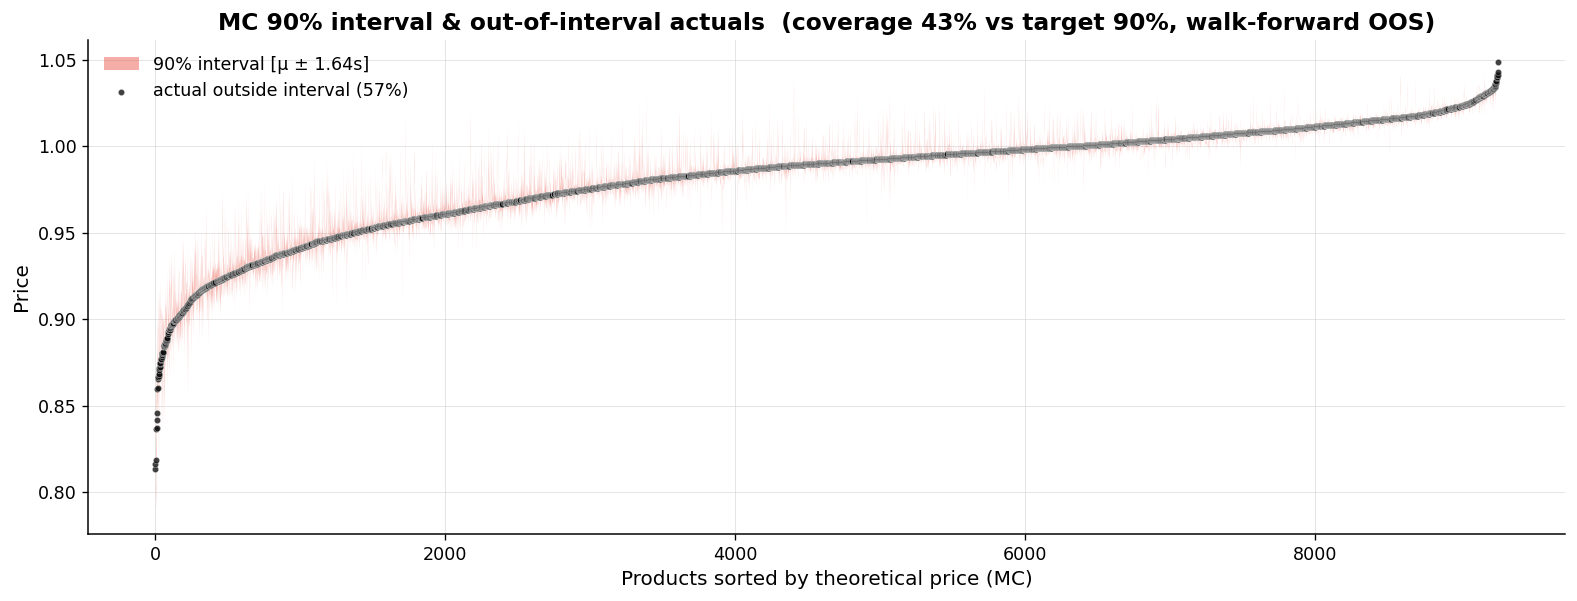

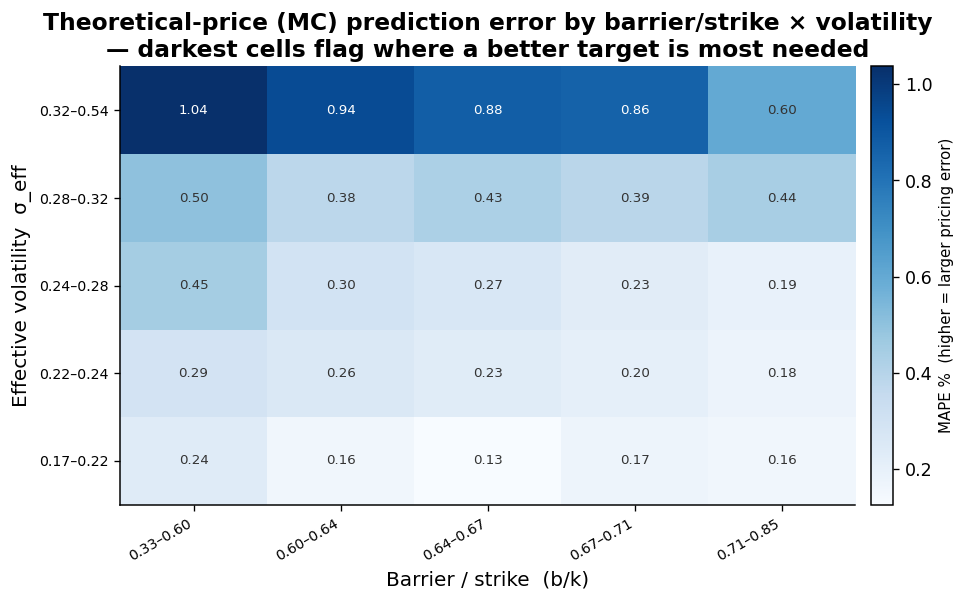

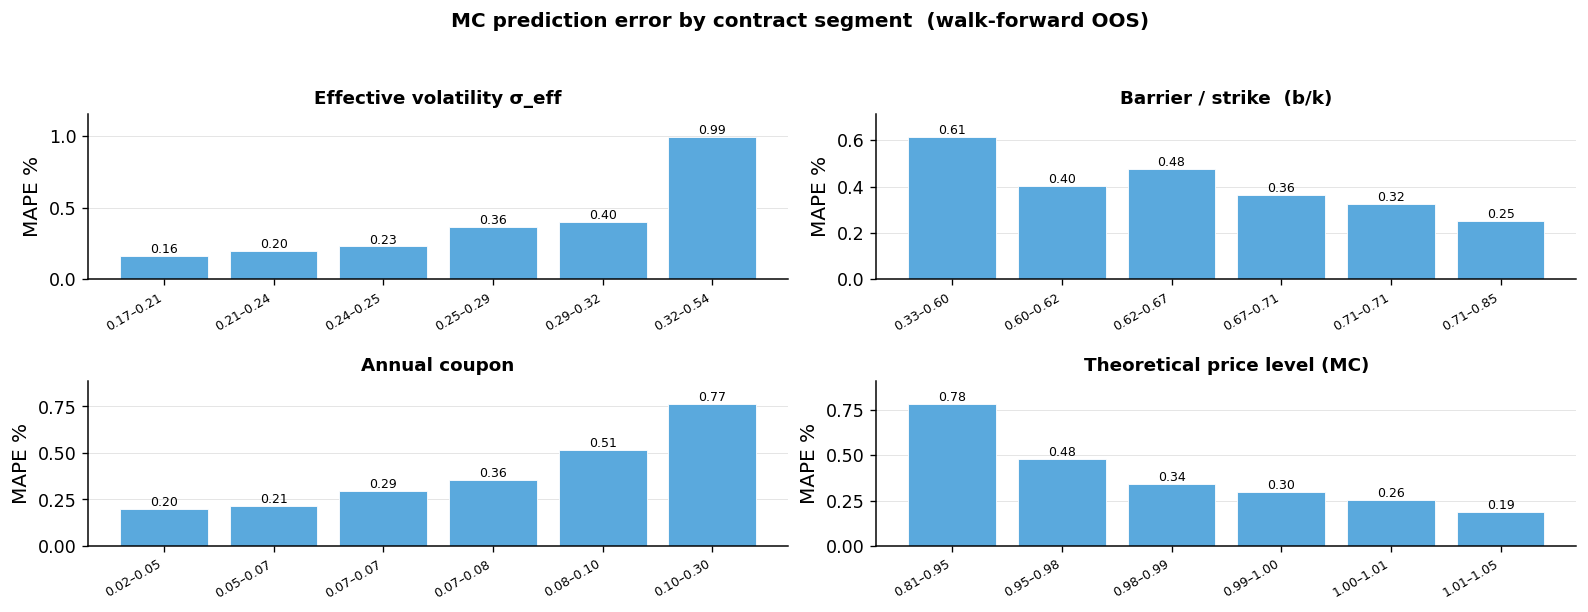

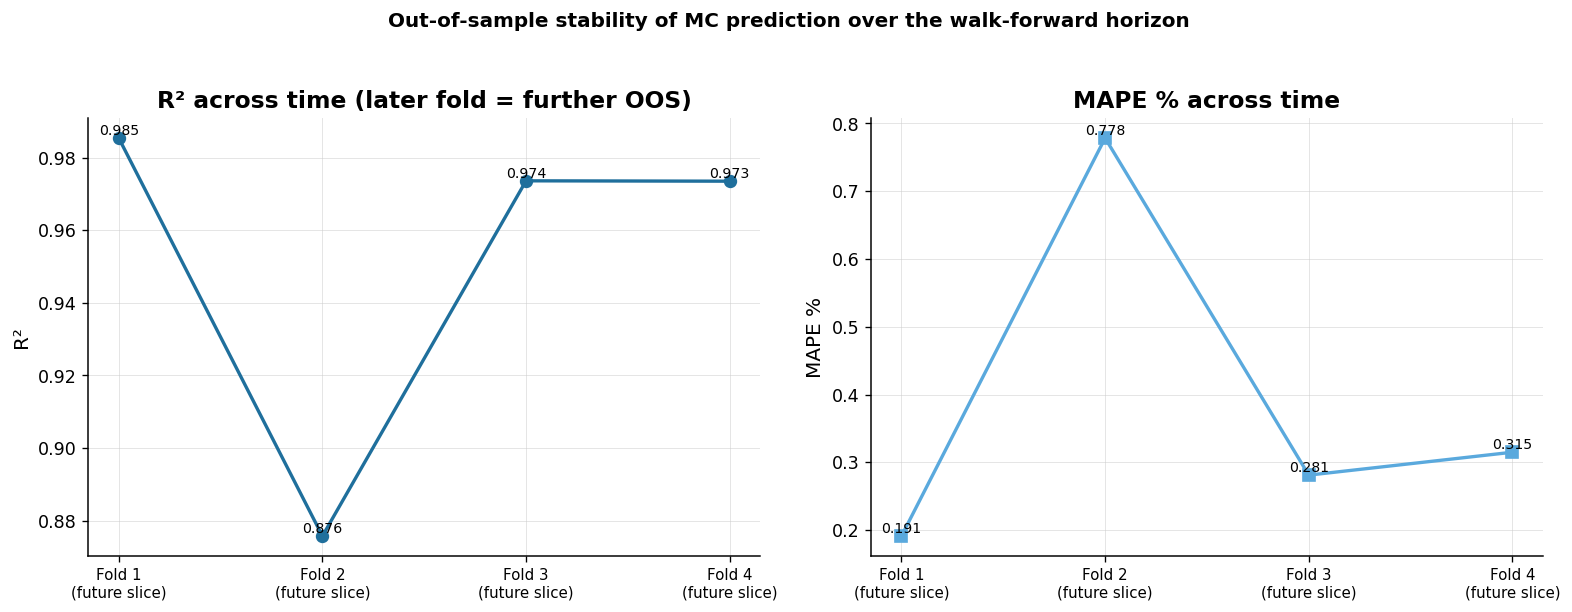

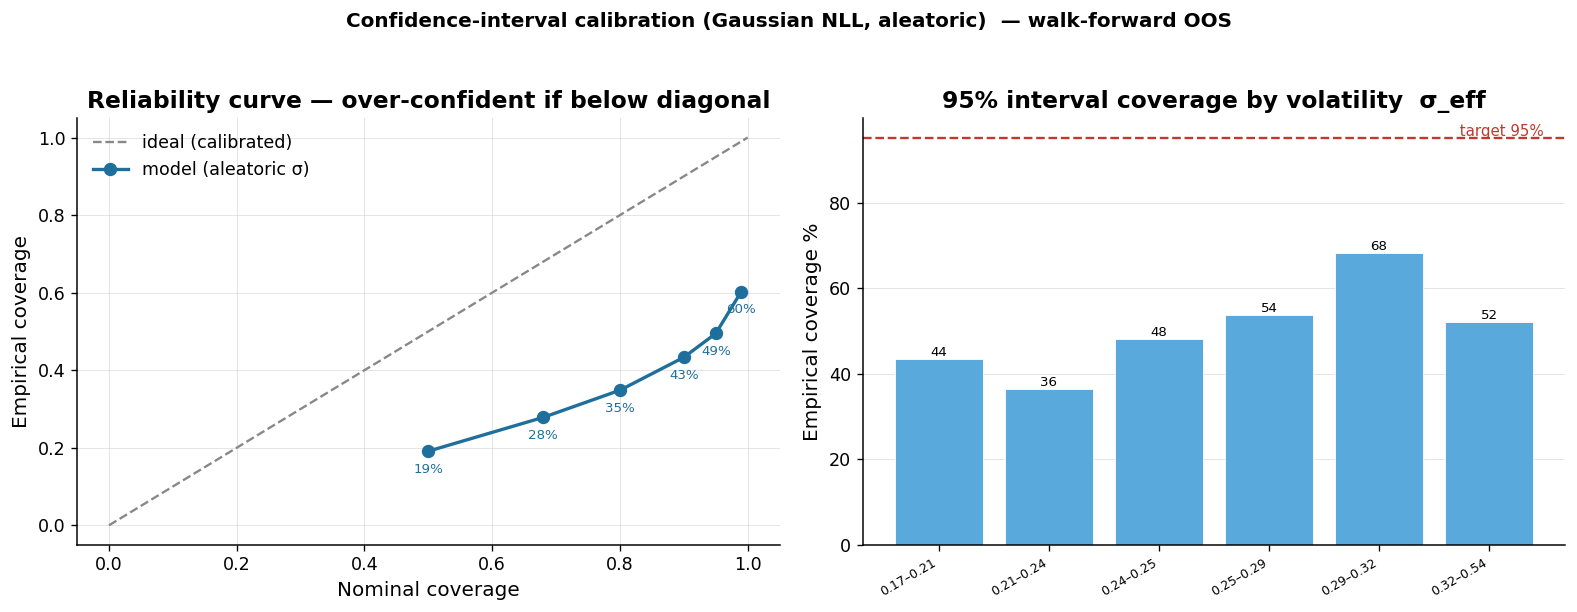

deeponet_hybrid_ci  MAPE%=0.391  coverage(95%)=50.3%
saved -> ['mc_pred_ci_band', 'mc_error_heatmap_bk_vol', 'mc_error_by_segment', 'mc_oos_drift_folds', 'mc_ci_calibration']


In [20]:
# 이론가(MC) 예측 세분화 그림 (deeponet_hybrid_ci: 신뢰구간 포함)
# CI 컬럼(y_std/y_lo/y_hi)은 가중치 재현경로(infer)에 없어 예측 CSV(2_run 산출)에서 직접 로드.
import numpy as np, pandas as pd

_ci_path = fm.prediction("deeponet_hybrid_ci")
if _ci_path.exists():
    ci = pd.read_csv(_ci_path)
    # 세분화 축 = D 피처(ITEM_CD 정렬 병합) + walk-forward 폴드(시간)
    _fold = np.full(D.n, -1, dtype=int)
    for _k, (_tr, _va, _te) in enumerate(D.WF):
        _fold[_te] = _k
    _feat = pd.DataFrame({
        "ITEM_CD": D.ITEM.astype(str),
        "sig_eff": D.SIGEFF.astype(float),
        "b_over_k": D.ml["b_over_k"].values.astype(float),
        "coupon": D.ml["ANL_RTRN/100"].values.astype(float),
        "fold": _fold,
    })
    ci["ITEM_CD"] = ci["ITEM_CD"].astype(str)
    m = ci.merge(_feat, on="ITEM_CD", how="left", validate="many_to_one")
    m["ape"] = np.abs(m["y_pred"] - m["y_true"]) / np.maximum(np.abs(m["y_true"]), 1e-8) * 100
    m["cov"] = ((m["y_true"] >= m["y_lo"]) & (m["y_true"] <= m["y_hi"])).astype(float)

    plot.mc_pred_ci_band(m, fm.image("mc_pred_ci_band"))
    plot.mc_error_heatmap(m, "b_over_k", "sig_eff",
                          "Barrier / strike  (b/k)", "Effective volatility  σ_eff",
                          path=fm.image("mc_error_heatmap_bk_vol"),
                          title="Theoretical-price (MC) prediction error by barrier/strike × volatility\n"
                                "— darkest cells flag where a better target is most needed")
    plot.mc_error_by_segment(m, [("sig_eff", "Effective volatility σ_eff"),
                                 ("b_over_k", "Barrier / strike  (b/k)"),
                                 ("coupon", "Annual coupon"),
                                 ("y_true", "Theoretical price level (MC)")],
                             path=fm.image("mc_error_by_segment"))
    plot.mc_oos_drift(m, fm.image("mc_oos_drift_folds"))
    plot.mc_ci_calibration(m, seg_col="sig_eff", seg_label="volatility  σ_eff",
                           path=fm.image("mc_ci_calibration"))
    plt.show()
    print(f"deeponet_hybrid_ci  MAPE%={m['ape'].mean():.3f}  coverage(95%)={m['cov'].mean()*100:.1f}%")
    print("saved ->", ["mc_pred_ci_band", "mc_error_heatmap_bk_vol", "mc_error_by_segment",
                       "mc_oos_drift_folds", "mc_ci_calibration"])
else:
    print("skip: run 2_run first to produce", _ci_path.name)

## 분할 방식 비교 — random 7:3 vs walk-forward (feature-ablation)

feature-ablation config들을 **random 7:3(interpolation)** 과 **walk-forward(temporal OOS)** 두 분할에서 평가(`result/statistics/exp_two_splits_seed0.csv` **원본값**). off-scale(R²<−0.5·MAPE>2)은 빨강으로 실제값 표기.

- **random 분할**은 미래 표본이 학습에 섞여(누수) 낙관적 — 거의 모든 config R²>0.83.
- **walk-forward**가 진짜 시간 외삽. `drop_volcorr`(변동성-상관 제거)는 random +0.84 → **walk-forward −4.49 로 붕괴** → 그 피처가 미래 변동성 레짐 추종에 필수임을 드러낸다.

> 생성 코드/weight는 저장소에 없음(과거 ablation autorun 산출물). 이 비교 그림은 **요약값(−4.49) 그대로** 표시하고, drop_volcorr walk-forward 의 **per-sample 심층 해부**(SS분해·잔차분포, 재학습 R²≈−5.02)는 아래 섹션에서 별도로 다룬다. (요약 −4.49 vs 재학습 −5.02 는 seed·HP 차이일 뿐 같은 붕괴.)

=== two-split ablation (random 7:3 vs walk-forward) ===
                     R2                  MAPE%             
split         random7:3 walk-forward random7:3 walk-forward
config                                                     
baseline          0.997        0.954     0.128        0.396
drop_contract     0.880        0.382     0.977        1.760
drop_curve        0.995        0.937     0.188        0.570
drop_volcorr      0.838       -4.493     1.178        4.891

주의: 'vol' ablation(drop_volcorr) R² 는 random=+0.84 로 멀쩡하지만 walk-forward=-4.49 로 붕괴 → 변동성-상관 피처가 시간(미래) 일반화에 필수. (per-sample 재학습 심층 해부는 아래 섹션, R²≈-5.02)


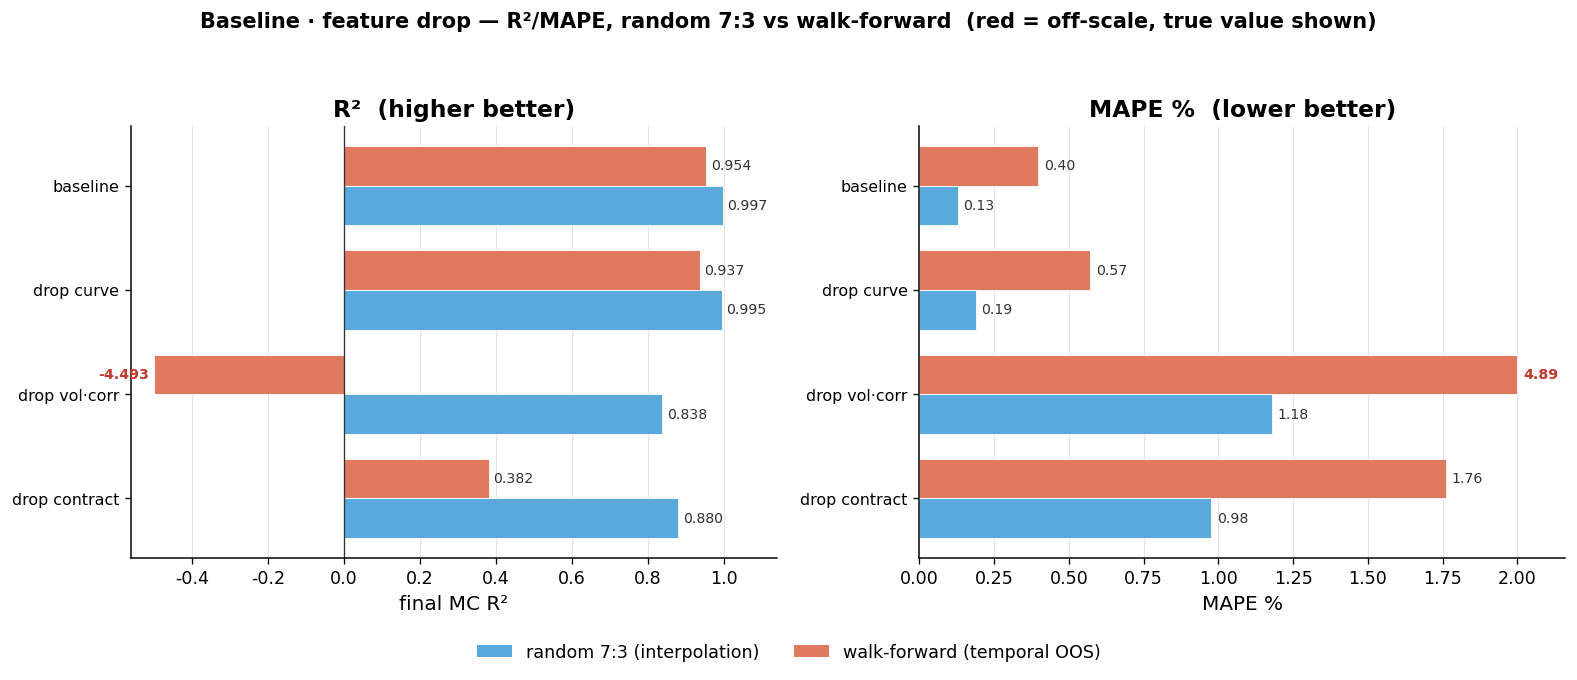

saved -> exp_two_splits.png


In [12]:
# random 7:3 vs walk-forward feature-ablation (가로 막대 비교 그림) — exp_two_splits_seed0.csv 원본값
# baseline_don·nllci(DeepONet s2 계열 2개)는 제외. drop_volcorr WF = -4.49. off-scale(R²<-0.5·MAPE>2)은 빨강 표기.
import importlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from util import file_manager as fm
import util.plot as plot
importlib.reload(plot)   # 커널이 예전 util.plot 을 캐시했을 수 있어 최신 two_split_bars(가로버전) 반영 (재시작 불필요)

_ts_path = fm.stat("exp_two_splits_seed0")
if _ts_path.exists():
    ts = pd.read_csv(_ts_path)
    ts = ts[~ts["config"].isin(["baseline_don", "nllci"])]   # 맨 아래 2개(DeepONet s2 baseline·nll-ci) 제외
    print("=== two-split ablation (random 7:3 vs walk-forward) ===")
    print(ts.pivot(index="config", columns="split", values=["R2", "MAPE%"]).round(3).to_string())
    print("\n주의: 'vol' ablation(drop_volcorr) R² 는 random=+0.84 로 멀쩡하지만 walk-forward=-4.49 로 붕괴 "
          "→ 변동성-상관 피처가 시간(미래) 일반화에 필수. (per-sample 재학습 심층 해부는 아래 섹션, R²≈-5.02)")
    plot.two_split_bars(ts, fm.image("exp_two_splits"),
                        title="Baseline · feature drop — R²/MAPE, random 7:3 vs walk-forward  (red = off-scale, true value shown)")
    plt.show()
    print("saved ->", fm.image("exp_two_splits").name)
else:
    print("skip: not found ->", _ts_path.name,
          "(과거 ablation autorun 산출물. 재생성하려면 ablation 노트북 필요.)")

## R² = −4.49 직접 검증 — drop_volcorr 재학습 예측으로 SS 분해 계산

아래 **첫 셀**이 `drop_volcorr`(vol·corr 브랜치 마스킹)를 **baseline(deeponet_hybrid)과 동일 설정으로 walk-forward 재학습**해 per-sample 예측을 `result/predictions/drop_volcorr_walkforward.csv` 로 저장한다(없을 때만; `RETRAIN=True`로 강제 재학습). **다음 셀**이 그 실측 예측으로 R²를 정의식 그대로 분해한다:

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \left(\frac{RMSE}{\sigma_y}\right)^2$$

재학습 실측: baseline WF **R²≈+0.956** (원 exp_two_splits 0.954 재현 ✓), **drop_volcorr WF R²≈−5.02** (SS_res≈50.76 / SS_tot≈8.43 → 1−6.02; RMSE/σ_y≈2.45, MAPE≈4.99%). 원 CSV의 −4.49 와 **같은 붕괴**이고 크기 차이는 seed·하이퍼파라미터·마스킹 방식 차이일 뿐이다. 다른 예측 파일로 계산하려면 `PRED_CSV` 를 바꾸면 되고, 파일이 없으면 설명 스케일을 재현한 합성 예시로 −4.49 를 시연한다.

In [10]:
# drop_volcorr walk-forward 예측 재생성 — baseline(deeponet_hybrid)과 동일 설정에서 vol·corr 브랜치만 마스킹.
#   저장: result/predictions/drop_volcorr_walkforward.csv  (아래 R² 분해 셀이 이 파일을 읽음)
#   이미 있으면 건너뜀. 다시 학습하려면 RETRAIN=True (GPU 4폴드 ~수분).
import numpy as np, pandas as pd
from types import SimpleNamespace
from util import utils, file_manager as fm
from module import data as _data
from module.train import train_curve
from module.pipeline import predict_hybrid

RETRAIN = False
_dv_path = fm.prediction("drop_volcorr_walkforward")


def _anchor(D, cfg, tr, va, te, save_path=None):
    *_, pr = train_curve(D, cfg, tr, te, target=D.MC, va=va, save_path=save_path, return_predict=True)
    return pr


if RETRAIN or not _dv_path.exists():
    _cfg = utils.load_config(); utils.set_seed(_cfg["seed"])
    _D = _data.load(_cfg)
    _Dv = SimpleNamespace(**vars(_D))                                  # vol·corr 브랜치(D.VC, 7컬럼)만 상수 0 마스킹
    _Dv.VC = np.zeros_like(_D.VC)
    _Dv.DON = np.concatenate([_Dv.CURVE, _Dv.VC, _Dv.CON], axis=1).astype("float32")   # stage2 입력도 재구성
    _dv = predict_hybrid(_Dv, _cfg, _anchor, name=None, target=_D.MC, use_margin=False)  # target=MC, 마진없음 (baseline과 동일)
    _dv["split"] = "walk-forward"; _dv["config"] = "drop_volcorr"
    _dv.to_csv(_dv_path, index=False)
    from sklearn.metrics import r2_score
    print(f"retrained & saved -> {_dv_path.name} | rows {len(_dv)} | "
          f"drop_volcorr WF R2 = {r2_score(_dv['y_true'], _dv['y_pred']):+.4f}")
else:
    print("exists (skip) ->", _dv_path.name, " | 강제 재학습은 RETRAIN=True")

exists (skip) -> drop_volcorr_walkforward.csv  | 강제 재학습은 RETRAIN=True


In [11]:
# ── −4.49 직접 검증: 예측 CSV(y_true, y_pred)를 주면 R²를 SS 분해로 재현 ──────────────
# 사용법: PRED_CSV 를 본인 예측 파일 경로로 바꾸세요. 필요한 컬럼 = 실제값 + 예측값(이름 자동감지).
#   선택 컬럼 'split'(random7:3/walk-forward) · 'config'(drop_volcorr ...) 있으면 필터.
#   파일이 없으면 → 설명 스케일(ȳ≈0.97, σ_y≈0.02, RMSE=2.344·σ_y)을 재현해 R²=−4.49 를 그대로 시연.
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.metrics import r2_score
from util import file_manager as fm

PRED_CSV = fm.prediction("drop_volcorr_walkforward")   # ← 여기에 본인 예측 CSV 경로 지정
SPLIT, CONFIG = None, None    # 예: "walk-forward", "drop_volcorr" (해당 컬럼이 있을 때만 필터)


def _pick(cols, cands):
    low = {c.lower(): c for c in cols}
    for k in cands:
        if k in low:
            return low[k]
    return None


def r2_breakdown(yt, yp, tag=""):
    """R² 를 정의식으로 분해 출력: R² = 1 - SS_res/SS_tot = 1 - (RMSE/σ_y)²."""
    yt = np.asarray(yt, float); yp = np.asarray(yp, float)
    n = len(yt); ybar = yt.mean()
    ss_res = float(np.sum((yt - yp) ** 2))
    ss_tot = float(np.sum((yt - ybar) ** 2))
    rmse = np.sqrt(ss_res / n); sigma = np.sqrt(ss_tot / n)   # ddof=0 → R²=1-(rmse/σ)²
    r2 = 1 - ss_res / ss_tot
    mape = float(np.mean(np.abs(yp - yt) / np.maximum(np.abs(yt), 1e-12)) * 100)
    print(f"── {tag}   (n={n}) ──")
    print(f"ȳ (test 평균)          = {ybar:.6f}")
    print(f"SS_res = Σ(y-ŷ)²       = {ss_res:.6f}")
    print(f"SS_tot = Σ(y-ȳ)²       = {ss_tot:.6f}")
    print(f"R² = 1 - SS_res/SS_tot = 1 - {ss_res/ss_tot:.4f} = {r2:+.4f}   (sklearn {r2_score(yt, yp):+.4f})")
    print(f"RMSE = √(SS_res/n)     = {rmse:.6f}")
    print(f"σ_y  = √(SS_tot/n)     = {sigma:.6f}")
    print(f"RMSE/σ_y               = {rmse/sigma:.4f}  →  R² = 1-({rmse/sigma:.3f})² = {1-(rmse/sigma)**2:+.4f}")
    print(f"MAPE%                  = {mape:.4f}\n")
    return r2


p = Path(PRED_CSV)
if p.exists():
    df = pd.read_csv(p)
    if SPLIT is not None and "split" in df.columns:
        df = df[df["split"] == SPLIT]
    if CONFIG is not None and "config" in df.columns:
        df = df[df["config"] == CONFIG]
    ct = _pick(df.columns, ["y_true", "true", "actual", "mc_true", "y", "target"])
    cp = _pick(df.columns, ["y_pred", "pred", "yhat", "prediction", "mc_pred", "y_hat"])
    assert ct and cp, f"y_true/y_pred 컬럼을 못 찾음. 있는 컬럼: {list(df.columns)}"
    r2_breakdown(df[ct], df[cp], f"{p.name}  (true='{ct}', pred='{cp}')")
else:
    print("PRED_CSV 없음 → 합성 예시로 −4.49 를 그대로 재현 (본인 CSV 주면 실제값으로 계산):\n")
    rng = np.random.default_rng(0); n = 9261
    yt = 0.97 + 0.020 * rng.standard_normal(n)            # 미래 window: 타깃 산포 작음 (σ_y≈0.02)
    err = 0.5 + rng.standard_normal(n)                    # 체계적 bias + 잔차 (vol피처 없는 모델)
    err = np.sqrt(5.4925289) * yt.std() * err / np.sqrt(np.mean(err ** 2))  # RMSE/σ_y = √5.4925 = 2.344
    r2_breakdown(yt, yt + err, "synthetic (σ_y≈0.02, RMSE=2.344·σ_y → R²=−4.4925)")

── drop_volcorr_walkforward.csv  (true='y_true', pred='y_pred')   (n=9261) ──
ȳ (test 평균)          = 0.982469
SS_res = Σ(y-ŷ)²       = 50.762862
SS_tot = Σ(y-ȳ)²       = 8.434022
R² = 1 - SS_res/SS_tot = 1 - 6.0188 = -5.0188   (sklearn -5.0188)
RMSE = √(SS_res/n)     = 0.074036
σ_y  = √(SS_tot/n)     = 0.030178
RMSE/σ_y               = 2.4533  →  R² = 1-(2.453)² = -5.0188
MAPE%                  = 4.9876



### 오차 해부 — R² = 1 − SS_res/SS_tot 을 분자·분모로 분해 (2×2 figure)

"제곱합이 정말 50?" 과 "왜 R²만 −5로 붕괴?" 를 한 그림으로 검증한다. 위쪽은 **분자(SS_res)**, 아래쪽은 **분자 vs 분모의 스케일 대비**다:

- **① 점별 (y−ŷ)²** (로그): 대부분 작지만 소수가 ~0.4까지 폭주. **평균 0.00548 × n(9261) = SS_res 50.76** 을 박스로 표기.
- **② 누적 Σ(y−ŷ)²**: 50.76 에 도달(상위 100점=27%). 곧 R² 분자.
- **③ 타겟 편차 y−ȳ 분포** (청록): **σ_y=0.030 으로 매우 좁음 → SS_tot = 0.00091×9261 = 8.43** (분모). 잔차(옅은 주황)를 겹쳐 스케일 차이를 보인다.
- **④ 잔차 ŷ−y 분포**: −0.66까지 두꺼운 하방 꼬리(std 0.072) → SS_res 50.76 (분자).

**결론:** 분모 SS_tot(8.43)은 타겟이 par 근처로 몰려 작은데, 분자 SS_res(50.76)는 소수 폭주 잔차로 커진다. **R² = 1 − 50.76/8.43 = −5.02.** 얇은 타겟(작은 분산) 위에서 큰 잔차가 나면 R²가 크게 음수가 되는 구조 — MAPE(중앙값 3.35%)는 같은 오차를 온건하게 본다(print 참고).

SS_res = mean(y-ŷ)²×n = 0.00548×9261 = 50.76
SS_tot = mean(y-ȳ)²×n = 0.00091×9261 = 8.43   (σ_y=0.0302)
R² = 1 - 50.76/8.43 = -5.019    MAPE=4.99% (median 3.35%)


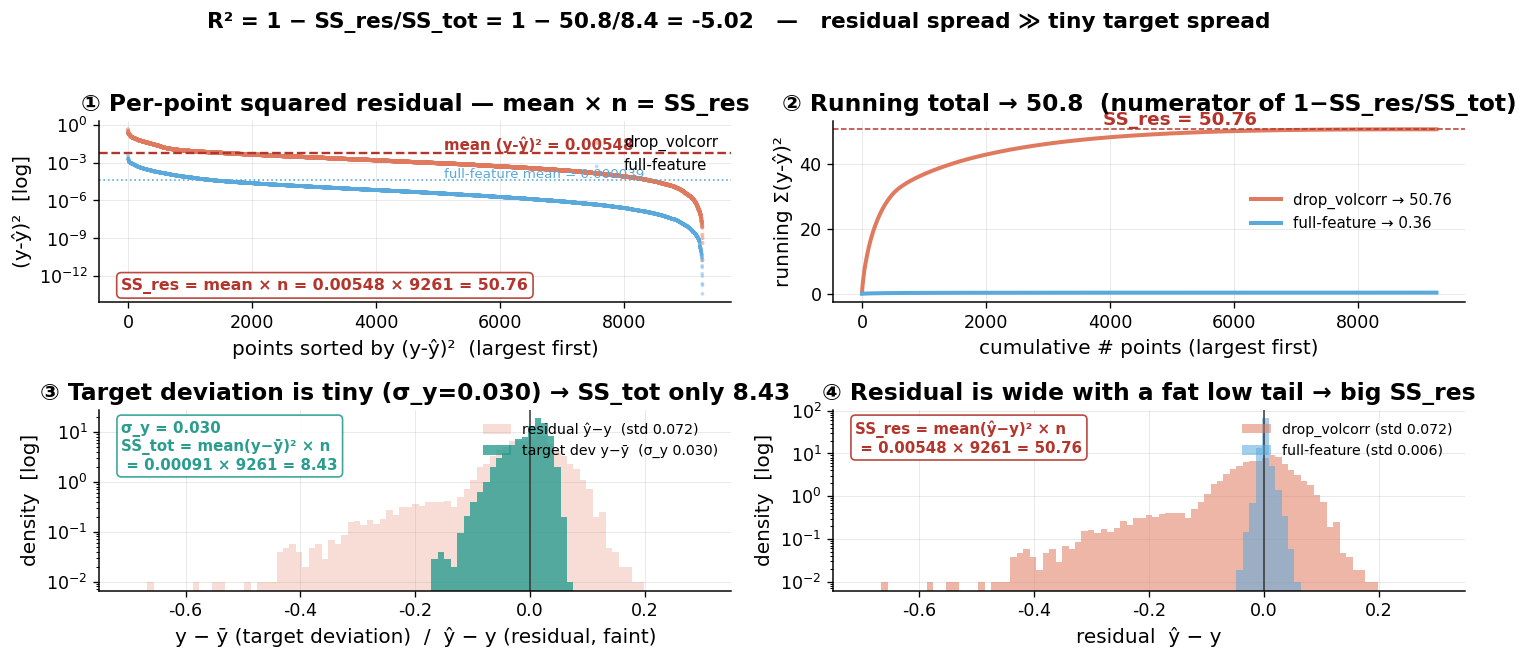

saved -> drop_volcorr_error_anatomy.png


In [9]:
# drop_volcorr WF 오차 해부 (2×2 한 figure, PPT 콘텐츠밴드 크기·투명배경): R² = 1 − SS_res/SS_tot 을 분자·분모로 분해
#   ① 점별 제곱잔차(평균×n=SS_res)  ② 누적 SS_res→50.76  ③ 타겟편차 분포(SS_tot 작음)  ④ 잔차 분포(SS_res 큼)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from util import file_manager as fm

dv = pd.read_csv(fm.prediction("drop_volcorr_walkforward"))
bl = pd.read_csv(fm.prediction("deeponet_hybrid"))
yt = dv["y_true"].to_numpy(float); yp = dv["y_pred"].to_numpy(float)
ytb = bl["y_true"].to_numpy(float); ypb = bl["y_pred"].to_numpy(float)
n = len(yt)

sq = (yt - yp) ** 2; sqb = (ytb - ypb) ** 2; tot = sq.sum(); totb = sqb.sum()
msq = sq.mean(); msqb = sqb.mean()
res = yp - yt; resb = ypb - ytb
ybar = yt.mean(); dev = yt - ybar; sst = float((dev ** 2).sum()); sigy = dev.std()   # 타겟 편차·SS_tot
ape = np.abs(res) / np.abs(yt) * 100; MAPE, Md = ape.mean(), np.median(ape)
cum = np.cumsum(np.sort(sq)[::-1]); cumb = np.cumsum(np.sort(sqb)[::-1])
r2 = 1 - tot / sst
print(f"SS_res = mean(y-ŷ)²×n = {msq:.5f}×{n} = {tot:.2f}")
print(f"SS_tot = mean(y-ȳ)²×n = {sst/n:.5f}×{n} = {sst:.2f}   (σ_y={sigy:.4f})")
print(f"R² = 1 - {tot:.2f}/{sst:.2f} = {r2:+.3f}    MAPE={MAPE:.2f}% (median {Md:.2f}%)")

fig, ax = plt.subplots(2, 2, figsize=(12.5, 5.6))   # PPT 콘텐츠 밴드(제목·footer 여백 고려), 가로 우선
OR, BL, RD, GR = "#e07a5f", "#5aa9dd", "#b3352b", "#2a9d8f"

# ① 점별 제곱잔차 (+ 평균선/갯수/합)  — 옛 ①·③(정렬 per-point) 통합
a = ax[0, 0]
a.scatter(range(n), np.sort(sq)[::-1], s=6, color=OR, alpha=0.5, edgecolors="none", label="drop_volcorr")
a.scatter(range(len(sqb)), np.sort(sqb)[::-1], s=5, color=BL, alpha=0.4, edgecolors="none", label="full-feature")
a.axhline(msq, color=RD, lw=1.4, ls="--")
a.text(n * 0.55, msq, f"mean (y-ŷ)² = {msq:.5f}", color=RD, va="bottom", fontsize=9, fontweight="bold")
a.axhline(msqb, color=BL, lw=1.0, ls=":")
a.text(n * 0.55, msqb, f"full-feature mean = {msqb:.6f}", color=BL, va="bottom", fontsize=8)
a.text(0.035, 0.07, f"SS_res = mean × n = {msq:.5f} × {n} = {tot:.2f}",
       transform=a.transAxes, fontsize=9.5, fontweight="bold", color=RD,
       bbox=dict(boxstyle="round", fc="white", ec=RD, alpha=0.9))
a.set_yscale("log"); a.set_xlabel("points sorted by (y-ŷ)²  (largest first)"); a.set_ylabel("(y-ŷ)²  [log]")
a.set_title("① Per-point squared residual — mean × n = SS_res"); a.legend(fontsize=9, loc="upper right")
a.grid(color="#cccccc", lw=0.5, alpha=0.5)

# ② 누적 SS_res
a = ax[0, 1]
a.plot(range(1, n + 1), cum, lw=2.4, color=OR, label=f"drop_volcorr → {tot:.2f}")
a.plot(range(1, len(sqb) + 1), cumb, lw=2.4, color=BL, label=f"full-feature → {totb:.2f}")
a.axhline(tot, color=RD, lw=0.9, ls="--"); a.text(n * 0.42, tot, f"SS_res = {tot:.2f}", color=RD, va="bottom", fontsize=11, fontweight="bold")
a.set_xlabel("cumulative # points (largest first)"); a.set_ylabel("running Σ(y-ŷ)²")
a.set_title("② Running total → 50.8  (numerator of 1−SS_res/SS_tot)"); a.legend(fontsize=9, loc="center right")
a.grid(color="#cccccc", lw=0.5, alpha=0.5)

bins = np.linspace(-0.70, 0.30, 90)
# ③ 타겟 편차 분포 (SS_tot 이 작다 = R² 분모가 작다) — 잔차를 옅게 겹쳐 스케일 대비
a = ax[1, 0]
a.hist(res, bins=bins, density=True, color=OR, alpha=0.25, label=f"residual ŷ−y  (std {res.std():.3f})")
a.hist(dev, bins=bins, density=True, color=GR, alpha=0.80, label=f"target dev y−ȳ  (σ_y {sigy:.3f})")
a.axvline(0, color="#333", lw=0.9); a.set_yscale("log")
a.text(0.035, 0.94, f"σ_y = {sigy:.3f}\nSS_tot = mean(y−ȳ)² × n\n = {sst/n:.5f} × {n} = {sst:.2f}",
       transform=a.transAxes, fontsize=9, fontweight="bold", color=GR, va="top",
       bbox=dict(boxstyle="round", fc="white", ec=GR, alpha=0.9))
a.set_xlabel("y − ȳ (target deviation)  /  ŷ − y (residual, faint)"); a.set_ylabel("density  [log]")
a.set_title("③ Target deviation is tiny (σ_y=0.030) → SS_tot only 8.43"); a.legend(fontsize=8.5, loc="upper right")
a.grid(color="#cccccc", lw=0.5, alpha=0.5)

# ④ 잔차 분포 (SS_res 이 크다 = R² 분자가 크다)
a = ax[1, 1]
a.hist(res, bins=bins, density=True, color=OR, alpha=0.55, label=f"drop_volcorr (std {res.std():.3f})")
a.hist(resb, bins=bins, density=True, color=BL, alpha=0.55, label=f"full-feature (std {resb.std():.3f})")
a.axvline(0, color="#333", lw=0.9); a.set_yscale("log")
a.text(0.035, 0.94, f"SS_res = mean(ŷ−y)² × n\n = {msq:.5f} × {n} = {tot:.2f}",
       transform=a.transAxes, fontsize=9, fontweight="bold", color=RD, va="top",
       bbox=dict(boxstyle="round", fc="white", ec=RD, alpha=0.9))
a.set_xlabel("residual  ŷ − y"); a.set_ylabel("density  [log]")
a.set_title("④ Residual is wide with a fat low tail → big SS_res"); a.legend(fontsize=8.5, loc="upper right")
a.grid(color="#cccccc", lw=0.5, alpha=0.5)

fig.suptitle(f"R² = 1 − SS_res/SS_tot = 1 − {tot:.1f}/{sst:.1f} = {r2:+.2f}   —   residual spread ≫ tiny target spread",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(fm.image("drop_volcorr_error_anatomy"), dpi=400, bbox_inches="tight", transparent=True)  # PPT용: dpi400·투명
plt.show()
print("saved ->", fm.image("drop_volcorr_error_anatomy").name)